In [1]:
pip install mysql-connector-python pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import mysql.connector
import pandas as pd
conn=mysql.connector.connect(
    host='localhost',
    user='root',
    password='@12345',
    database='ftn'
)
query="select * from city_day;"

data=pd.read_sql(query,conn)
conn.close()

C:\Users\Rishita\AppData\Local\Temp\ipykernel_20304\1478815874.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data=pd.read_sql(query,conn)


In [3]:
data

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toulene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,0.00,0.00,0.92,18.22,17.15,0.00,0.92,27.64,133.36,0.00,0.02,0.00,0.0,None
1,Ahmedabad,2015-01-02,0.00,0.00,0.97,15.69,16.46,0.00,0.97,24.55,34.06,3.68,5.50,3.77,0.0,None
2,Ahmedabad,2015-01-03,0.00,0.00,17.40,19.30,29.70,0.00,17.40,29.07,30.70,6.80,16.40,2.25,0.0,None
3,Ahmedabad,2015-01-04,0.00,0.00,1.70,18.48,17.97,0.00,1.70,18.59,36.08,4.43,10.14,1.00,0.0,None
4,Ahmedabad,2015-01-05,0.00,0.00,22.10,21.42,37.76,0.00,22.10,39.33,39.31,7.01,18.89,2.78,0.0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory


In [8]:
print(len(data))

29531


In [10]:
data.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toulene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [13]:
print((data == 0).sum())

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4925
NH3           10328
CO             4387
SO2            3854
O3             4022
Benzene        9425
Toulene       10902
Xylene        19856
AQI            4681
AQI_Bucket        0
dtype: int64


In [5]:
import numpy as np

pollutant_columns= ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toulene','Xylene','AQI']
for col in pollutant_columns:
    data[col]=data[col].replace(['',' '],np.nan)
    data[col]=data[col].replace(0,np.nan)

In [6]:
data[pollutant_columns].isnull().sum()

PM2.5       4598
PM10       11140
NO          3582
NO2         3585
NOx         4925
NH3        10328
CO          4387
SO2         3854
O3          4022
Benzene     9425
Toulene    10902
Xylene     19856
AQI         4681
dtype: int64

In [7]:
for cols in pollutant_columns:
    data[cols].fillna(data[cols].median(),inplace=True)

C:\Users\Rishita\AppData\Local\Temp\ipykernel_20304\1108470189.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[cols].fillna(data[cols].median(),inplace=True)
C:\Users\Rishita\AppData\Local\Temp\ipykernel_20304\1108470189.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



In [8]:
data['City'] = data['City'].str.strip().str.lower()

In [9]:
data['AQI_Bucket'] = data['AQI_Bucket'].str.strip().str.lower()

In [9]:
data

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toulene,Xylene,AQI,AQI_Bucket
0,ahmedabad,2015-01-01,48.57,95.68,0.92,18.22,17.15,15.85,0.92,27.64,133.36,1.56,0.02,1.48,118.0,None
1,ahmedabad,2015-01-02,48.57,95.68,0.97,15.69,16.46,15.85,0.97,24.55,34.06,3.68,5.50,3.77,118.0,None
2,ahmedabad,2015-01-03,48.57,95.68,17.40,19.30,29.70,15.85,17.40,29.07,30.70,6.80,16.40,2.25,118.0,None
3,ahmedabad,2015-01-04,48.57,95.68,1.70,18.48,17.97,15.85,1.70,18.59,36.08,4.43,10.14,1.00,118.0,None
4,ahmedabad,2015-01-05,48.57,95.68,22.10,21.42,37.76,15.85,22.10,39.33,39.31,7.01,18.89,2.78,118.0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,good
29527,visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,satisfactory
29528,visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,1.48,68.0,satisfactory
29529,visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,1.56,4.03,1.48,54.0,satisfactory


In [10]:
data['Date']=pd.to_datetime(data['Date'])

In [11]:
data.isnull().sum()

City             0
Date             0
PM2.5            0
PM10             0
NO               0
NO2              0
NOx              0
NH3              0
CO               0
SO2              0
O3               0
Benzene          0
Toulene          0
Xylene           0
AQI              0
AQI_Bucket    4681
dtype: int64

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        29531 non-null  object        
 1   Date        29531 non-null  datetime64[ns]
 2   PM2.5       29531 non-null  float64       
 3   PM10        29531 non-null  float64       
 4   NO          29531 non-null  float64       
 5   NO2         29531 non-null  float64       
 6   NOx         29531 non-null  float64       
 7   NH3         29531 non-null  float64       
 8   CO          29531 non-null  float64       
 9   SO2         29531 non-null  float64       
 10  O3          29531 non-null  float64       
 11  Benzene     29531 non-null  float64       
 12  Toulene     29531 non-null  float64       
 13  Xylene      29531 non-null  float64       
 14  AQI         29531 non-null  float64       
 15  AQI_Bucket  24850 non-null  object        
dtypes: datetime64[ns](1), 

In [13]:
data['Month']=data['Date'].dt.month

In [14]:
data['Monthly_AQI'] = data.groupby('Month')['AQI'].transform('mean')

In [35]:
data

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toulene,Xylene,AQI,AQI_Bucket,Month,Monthly_AQI
0,Ahmedabad,2015-01-01,48.57,95.68,0.92,18.22,17.15,15.85,0.92,27.64,133.36,1.56,0.02,1.48,118.0,,1,210.856925
1,Ahmedabad,2015-01-02,48.57,95.68,0.97,15.69,16.46,15.85,0.97,24.55,34.06,3.68,5.50,3.77,118.0,,1,210.856925
2,Ahmedabad,2015-01-03,48.57,95.68,17.40,19.30,29.70,15.85,17.40,29.07,30.70,6.80,16.40,2.25,118.0,,1,210.856925
3,Ahmedabad,2015-01-04,48.57,95.68,1.70,18.48,17.97,15.85,1.70,18.59,36.08,4.43,10.14,1.00,118.0,,1,210.856925
4,Ahmedabad,2015-01-05,48.57,95.68,22.10,21.42,37.76,15.85,22.10,39.33,39.31,7.01,18.89,2.78,118.0,,1,210.856925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good,6,119.833155
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory,6,119.833155
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,1.48,68.0,Satisfactory,6,119.833155
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,1.56,4.03,1.48,54.0,Satisfactory,6,119.833155


In [15]:
data['PM25_PM10_ratio']=data['PM2.5']/data['PM10']

In [16]:
data

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toulene,Xylene,AQI,AQI_Bucket,Month,Monthly_AQI,PM25_PM10_ratio
0,ahmedabad,2015-01-01,48.57,95.68,0.92,18.22,17.15,15.85,0.92,27.64,133.36,1.56,0.02,1.48,118.0,None,1,210.856925,0.507630
1,ahmedabad,2015-01-02,48.57,95.68,0.97,15.69,16.46,15.85,0.97,24.55,34.06,3.68,5.50,3.77,118.0,None,1,210.856925,0.507630
2,ahmedabad,2015-01-03,48.57,95.68,17.40,19.30,29.70,15.85,17.40,29.07,30.70,6.80,16.40,2.25,118.0,None,1,210.856925,0.507630
3,ahmedabad,2015-01-04,48.57,95.68,1.70,18.48,17.97,15.85,1.70,18.59,36.08,4.43,10.14,1.00,118.0,None,1,210.856925,0.507630
4,ahmedabad,2015-01-05,48.57,95.68,22.10,21.42,37.76,15.85,22.10,39.33,39.31,7.01,18.89,2.78,118.0,None,1,210.856925,0.507630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,good,6,119.833155,0.294857
29527,visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,satisfactory,6,119.833155,0.329059
29528,visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,1.48,68.0,satisfactory,6,119.833155,0.348547
29529,visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,1.56,4.03,1.48,54.0,satisfactory,6,119.833155,0.333000


In [46]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="@12345",
    database="ftn"
)

cursor = conn.cursor()

insert_query = """
INSERT INTO city_day_clean
(City, Date, `PM2.5`, PM10, NO, NO2, NOx, NH3, CO, SO2, O3,
 Benzene, Toulene, Xylene, AQI, AQI_Bucket, Month, Monthly_AQI, PM25_PM10_Ratio)
VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
"""

for index, row in data.iterrows():
    cursor.execute(insert_query, tuple(row))

conn.commit()
cursor.close()
conn.close()

print("Cleaned data inserted successfully!")


Cleaned data inserted successfully!


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns


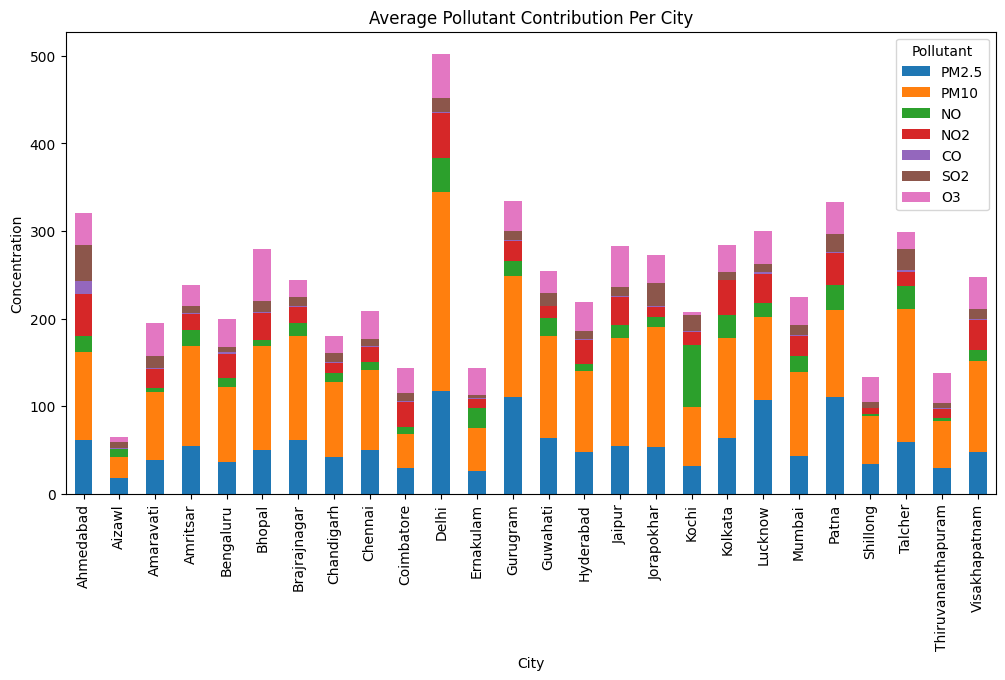

In [55]:
pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'CO', 'SO2', 'O3']
city_pollutant = data.groupby('City')[pollutants].mean()

city_pollutant.plot(kind='bar',stacked=True, figsize=(12,6))
plt.title("Average Pollutant Contribution Per City")
plt.ylabel("Concentration")
plt.xlabel("City")
plt.legend(title="Pollutant")
plt.show()


In [57]:
aqi=data['AQI_Bucket'].value_counts()
aqi

AQI_Bucket
Moderate        8829
Satisfactory    8224
                4681
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64

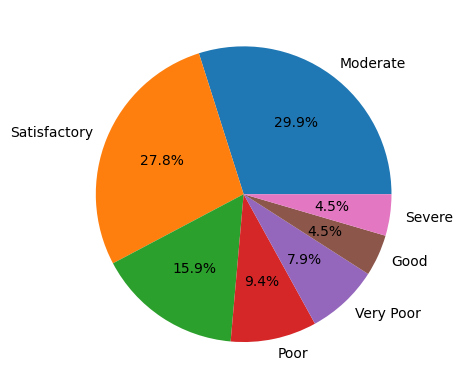

In [63]:
plt.pie(aqi,labels=aqi.index,autopct='%1.1f%%')
plt.show()

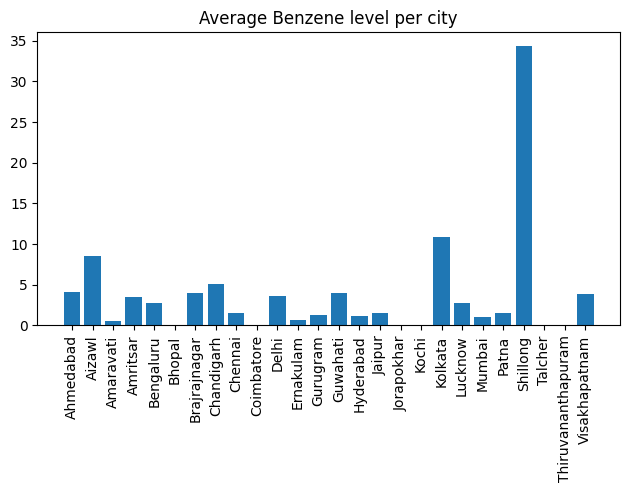

In [9]:
group_cities=data.groupby('City')['Benzene'].mean()
plt.bar(group_cities.index,group_cities.values)
plt.xticks(rotation=90)
plt.tight_layout()
plt.title('Average Benzene level per city')
plt.show()

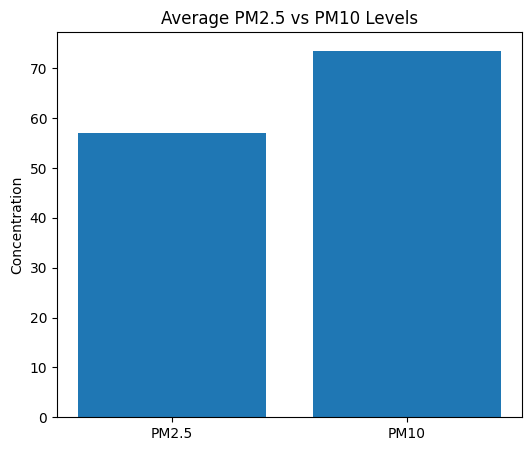

In [21]:
pollutants = data[['PM2.5', 'PM10']].mean()

plt.figure(figsize=(6,5))
plt.bar(pollutants.index, pollutants.values)
plt.title("Average PM2.5 vs PM10 Levels")
plt.ylabel("Concentration")
plt.show()


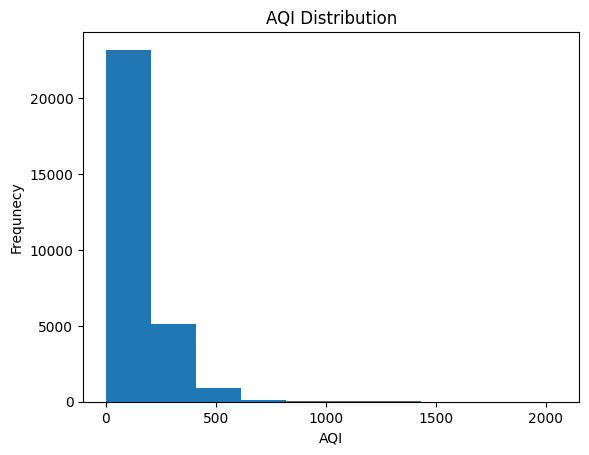

In [17]:
plt.hist(data['AQI'].dropna(),bins=10)
plt.title('AQI Distribution')
plt.xlabel('AQI')
plt.ylabel('Frequnecy')
plt.show()

In [19]:
data.to_excel("city_data_clean.xlsx", index=False)